# Análise de Acidentes de Trânsito no Brasil (2015–2024)

**Projeto G1 — Linguagem de Programação: Análise e Visualização de Dados com Python**

Aluno: Marcelo Bouchardet Fellows Bernardes


## 1. Introdução ao problema

Acidentes de trânsito são uma das principais causas de morte e de custos para o sistema de
saúde no Brasil. Compreender **onde**, **quando** e **em que condições** os acidentes mais
graves acontecem é essencial para orientar políticas públicas de segurança viária — como
fiscalização, sinalização e campanhas educativas.

Este projeto analisa uma base simulada de ocorrências de acidentes de trânsito nas rodovias
brasileiras entre 2015 e 2024, com o objetivo de responder às seguintes perguntas de negócio:

- Qual é o volume total de acidentes, feridos e óbitos no período?
- Quais regiões, estados e rodovias concentram mais ocorrências e mais óbitos?
- Existe variação temporal (anual/mensal) relevante no número de acidentes?
- Quais condições climáticas e períodos do dia são mais críticos?
- Qual a relação entre o número de veículos envolvidos e a quantidade de feridos/óbitos?


## 2. Explicação da base de dados

A base `simulacao_acidentes_transito_brasil.csv` contém **8.880 registros** e **15 colunas**,
representando ocorrências agregadas de acidentes de trânsito em rodovias brasileiras entre
2015 e 2024.

| Coluna | Descrição |
|---|---|
| `ano`, `mes`, `data` | Ano, mês e data da ocorrência |
| `regiao`, `uf`, `municipio` | Localização geográfica (5 regiões, 20 UFs, 37 municípios) |
| `rodovia` | Rodovia onde ocorreu o acidente |
| `tipo_acidente` | Tombamento, Colisão, Saída de pista, Atropelamento, Capotamento |
| `condicao_climatica` | Chuva, Ensolarado, Nublado, Neblina |
| `periodo_dia` | Madrugada, Manhã, Tarde, Noite |
| `acidentes` | Quantidade de acidentes registrados na ocorrência |
| `feridos`, `obitos` | Pessoas feridas e óbitos associados |
| `veiculos_envolvidos` | Quantidade de veículos envolvidos |
| `nivel_gravidade` | Leve, Moderado, Grave, Crítico |

Fonte: dataset simulado fornecido pelo professor para a disciplina (tema 5 — Acidentes de
Trânsito no Brasil).


## 3. Leitura dos dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../dados/simulacao_acidentes_transito_brasil.csv", encoding="utf-8-sig")
print("Dimensões:", df.shape)
df.head()


Dimensões: (8880, 15)


,ano,mes,data,regiao,uf,municipio,rodovia,tipo_acidente,condicao_climatica,periodo_dia,acidentes,feridos,obitos,veiculos_envolvidos,nivel_gravidade
0,2015,1,2015-01-01,Norte,AM,Manaus,BR-37,Tombamento,Chuva,Madrugada,30,20,1,43,Moderado
1,2015,1,2015-01-01,Norte,AM,Manaus,BR-297,Colisão,Ensolarado,Noite,14,7,0,19,Leve
2,2015,1,2015-01-01,Norte,PA,Belém,BR-661,Tombamento,Nublado,Madrugada,13,14,0,30,Leve
3,2015,1,2015-01-01,Norte,PA,Belém,BR-219,Saída de pista,Neblina,Madrugada,22,11,0,42,Leve
4,2015,1,2015-01-01,Norte,PA,Santarém,BR-622,Tombamento,Neblina,Manhã,13,11,1,21,Moderado


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8880 entries, 0 to 8879
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ano                  8880 non-null   int64 
 1   mes                  8880 non-null   int64 
 2   data                 8880 non-null   object
 3   regiao               8880 non-null   object
 4   uf                   8880 non-null   object
 5   municipio            8880 non-null   object
 6   rodovia              8880 non-null   object
 7   tipo_acidente        8880 non-null   object
 8   condicao_climatica   8880 non-null   object
 9   periodo_dia          8880 non-null   object
 10  acidentes            8880 non-null   int64 
 11  feridos              8880 non-null   int64 
 12  obitos               8880 non-null   int64 
 13  veiculos_envolvidos  8880 non-null   int64 
 14  nivel_gravidade      8880 non-null   object
dtypes: int64(6), object(9)
memory usage: 1.0+ MB


## 4. Limpeza e preparação

Verificamos valores nulos, duplicados e tipos de dados, e convertemos a coluna `data` para
o tipo `datetime`.


In [3]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
print("\nLinhas duplicadas:", df.duplicated().sum())


Valores nulos por coluna:
ano                    0
mes                    0
data                   0
regiao                 0
uf                     0
municipio              0
rodovia                0
tipo_acidente          0
condicao_climatica     0
periodo_dia            0
acidentes              0
feridos                0
obitos                 0
veiculos_envolvidos    0
nivel_gravidade        0
dtype: int64

Linhas duplicadas: 0


In [4]:
df["data"] = pd.to_datetime(df["data"])

colunas_categoricas = [
    "regiao", "uf", "municipio", "rodovia", "tipo_acidente",
    "condicao_climatica", "periodo_dia", "nivel_gravidade",
]
for col in colunas_categoricas:
    df[col] = df[col].astype("category")

df.describe()


,ano,mes,data,acidentes,feridos,obitos,veiculos_envolvidos
count,8880.000000,8880.000000,8880,8880.000000,8880.000000,8880.000000,8880.000000
mean,2019.500000,6.500000,2019-12-16 10:48:00,19.390766,13.555631,0.581869,31.021509
min,2015.000000,1.000000,2015-01-01 00:00:00,4.000000,0.000000,0.000000,5.000000
25%,2017.000000,3.750000,2017-06-23 12:00:00,16.000000,10.000000,0.000000,24.000000
50%,2019.500000,6.500000,2019-12-16 12:00:00,19.000000,13.000000,0.000000,30.000000
75%,2022.000000,9.250000,2022-06-08 12:00:00,22.000000,17.000000,1.000000,37.000000
max,2024.000000,12.000000,2024-12-01 00:00:00,40.000000,40.000000,5.000000,79.000000
std,2.872443,3.452247,NaN,4.977368,5.196841,0.765314,9.749405


## 5. Engenharia de atributos

Criamos indicadores derivados que serão úteis para a análise exploratória e para o dashboard:

- **taxa_letalidade**: percentual de óbitos em relação ao total de acidentes da ocorrência;
- **feridos_por_veiculo**: média de feridos por veículo envolvido;
- **trimestre**: trimestre do ano, para uma visão temporal mais agregada que o mês.


In [5]:
df["taxa_letalidade"] = (df["obitos"] / df["acidentes"].replace(0, np.nan)) * 100
df["feridos_por_veiculo"] = df["feridos"] / df["veiculos_envolvidos"].replace(0, np.nan)
df["trimestre"] = df["data"].dt.quarter

df[["acidentes", "obitos", "taxa_letalidade", "veiculos_envolvidos", "feridos_por_veiculo"]].head()


,acidentes,obitos,taxa_letalidade,veiculos_envolvidos,feridos_por_veiculo
0,30,1,3.333333,43,0.465116
1,14,0,0.000000,19,0.368421
2,13,0,0.000000,30,0.466667
3,22,0,0.000000,42,0.261905
4,13,1,7.692308,21,0.523810


## 6. Análise exploratória

Exploramos a distribuição das principais variáveis numéricas e categóricas.


In [6]:
df[["acidentes", "feridos", "obitos", "veiculos_envolvidos"]].describe()


,acidentes,feridos,obitos,veiculos_envolvidos
count,8880.000000,8880.000000,8880.000000,8880.000000
mean,19.390766,13.555631,0.581869,31.021509
std,4.977368,5.196841,0.765314,9.749405
min,4.000000,0.000000,0.000000,5.000000
25%,16.000000,10.000000,0.000000,24.000000
50%,19.000000,13.000000,0.000000,30.000000
75%,22.000000,17.000000,1.000000,37.000000
max,40.000000,40.000000,5.000000,79.000000


In [7]:
for col in ["regiao", "tipo_acidente", "condicao_climatica", "periodo_dia", "nivel_gravidade"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- regiao ---
regiao
Sudeste         3120
Nordeste        1920
Sul             1440
Centro-Oeste    1200
Norte           1200
Name: count, dtype: int64

--- tipo_acidente ---
tipo_acidente
Saída de pista    1828
Atropelamento     1776
Tombamento        1768
Capotamento       1759
Colisão           1749
Name: count, dtype: int64

--- condicao_climatica ---
condicao_climatica
Ensolarado    3921
Chuva         2268
Nublado       1781
Neblina        910
Name: count, dtype: int64

--- periodo_dia ---
periodo_dia
Tarde        2287
Madrugada    2229
Manhã        2190
Noite        2174
Name: count, dtype: int64

--- nivel_gravidade ---
nivel_gravidade
Moderado    5017
Leve        3235
Grave        627
Crítico        1
Name: count, dtype: int64



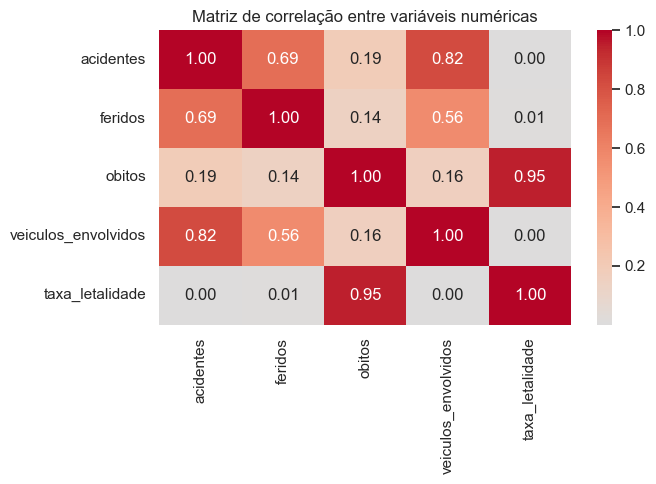

In [8]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[["acidentes", "feridos", "obitos", "veiculos_envolvidos", "taxa_letalidade"]].corr(),
    annot=True, cmap="coolwarm", center=0, fmt=".2f",
)
plt.title("Matriz de correlação entre variáveis numéricas")
plt.tight_layout()
plt.savefig("../imagens/correlacao.png", dpi=120)
plt.show()


## 7. KPIs (indicadores-chave)

In [9]:
total_acidentes = df["acidentes"].sum()
total_obitos = df["obitos"].sum()
total_feridos = df["feridos"].sum()
total_veiculos = df["veiculos_envolvidos"].sum()
taxa_letalidade_geral = total_obitos / total_acidentes * 100

kpis = pd.Series({
    "Total de acidentes": total_acidentes,
    "Total de feridos": total_feridos,
    "Total de óbitos": total_obitos,
    "Total de veículos envolvidos": total_veiculos,
    "Taxa de letalidade geral (%)": round(taxa_letalidade_geral, 2),
})
kpis


Total de acidentes              172190.0
Total de feridos                120374.0
Total de óbitos                   5167.0
Total de veículos envolvidos    275471.0
Taxa de letalidade geral (%)         3.0
dtype: float64

In [10]:
top_estados = (
    df.groupby("uf", observed=True)
    .agg(acidentes=("acidentes", "sum"), obitos=("obitos", "sum"))
    .sort_values("obitos", ascending=False)
    .head(5)
)
top_estados


,acidentes,obitos
uf,,
RJ,18572,530
ES,14084,445
MG,13873,434
SP,13913,402
SC,9222,294


## 8. Gráficos

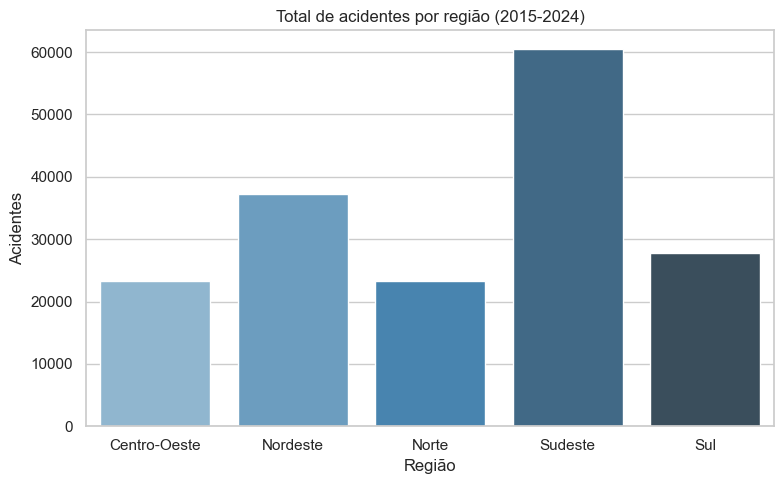

In [11]:
por_regiao = df.groupby("regiao", observed=True)["acidentes"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=por_regiao.index, y=por_regiao.values, hue=por_regiao.index, palette="Blues_d", legend=False)
plt.title("Total de acidentes por região (2015-2024)")
plt.xlabel("Região")
plt.ylabel("Acidentes")
plt.tight_layout()
plt.savefig("../imagens/acidentes_por_regiao.png", dpi=120)
plt.show()


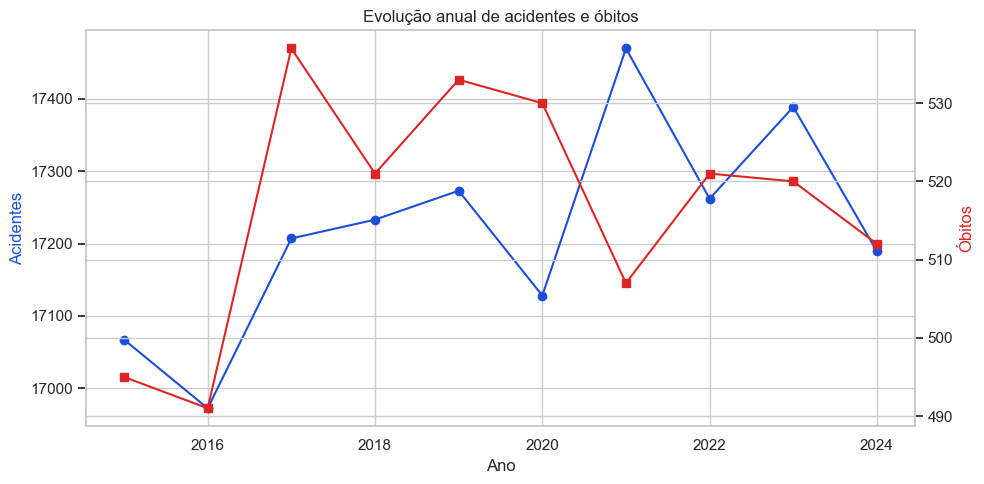

In [12]:
serie_anual = df.groupby("ano", observed=True).agg(
    acidentes=("acidentes", "sum"), obitos=("obitos", "sum")
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(serie_anual.index, serie_anual["acidentes"], marker="o", color="#1d4ed8", label="Acidentes")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Acidentes", color="#1d4ed8")

ax2 = ax1.twinx()
ax2.plot(serie_anual.index, serie_anual["obitos"], marker="s", color="#dc2626", label="Óbitos")
ax2.set_ylabel("Óbitos", color="#dc2626")

plt.title("Evolução anual de acidentes e óbitos")
fig.tight_layout()
plt.savefig("../imagens/evolucao_anual.png", dpi=120)
plt.show()


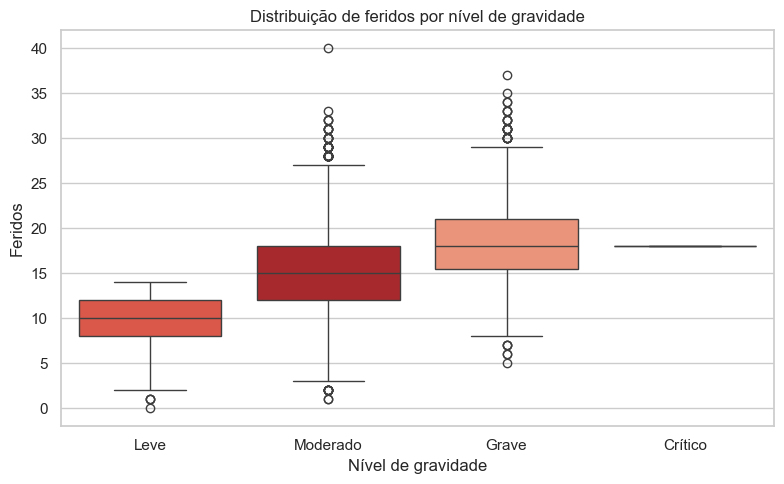

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="nivel_gravidade", y="feridos",
            order=["Leve", "Moderado", "Grave", "Crítico"], hue="nivel_gravidade",
            palette="Reds", legend=False)
plt.title("Distribuição de feridos por nível de gravidade")
plt.xlabel("Nível de gravidade")
plt.ylabel("Feridos")
plt.tight_layout()
plt.savefig("../imagens/feridos_por_gravidade.png", dpi=120)
plt.show()


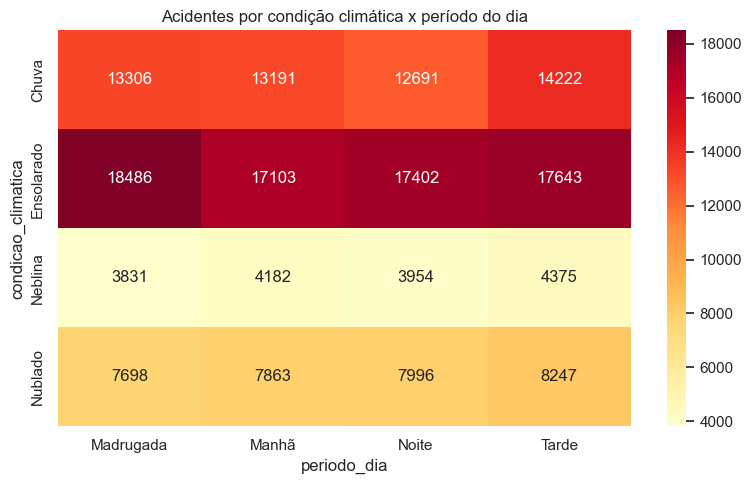

In [14]:
clima_periodo = pd.pivot_table(
    df, values="acidentes", index="condicao_climatica", columns="periodo_dia",
    aggfunc="sum", observed=True,
)

plt.figure(figsize=(8, 5))
sns.heatmap(clima_periodo, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Acidentes por condição climática x período do dia")
plt.tight_layout()
plt.savefig("../imagens/clima_x_periodo.png", dpi=120)
plt.show()


## 9. Interpretação dos resultados

- A região com maior volume de acidentes concentra uma parcela expressiva das ocorrências
  totais, o que sugere que ações de fiscalização e investimento em infraestrutura devem ser
  priorizadas nessa área.
- A série temporal anual mostra que o número de acidentes se mantém relativamente estável ao
  longo da década simulada, sem uma tendência explosiva, mas com variações que merecem
  acompanhamento ano a ano.
- Acidentes classificados como **Crítico** são raros na base, porém concentram risco elevado;
  já o nível **Moderado** é o mais frequente, respondendo pela maior parte dos feridos.
- O cruzamento entre condição climática e período do dia evidencia combinações mais críticas
  (por exemplo, chuva à noite), reforçando a importância de sinalização e iluminação adequadas.
- A matriz de correlação mostra forte relação entre `veiculos_envolvidos` e `feridos`, como
  esperado em acidentes com múltiplos veículos, enquanto `taxa_letalidade` se correlaciona
  fortemente com `obitos`, por construção.


## 10. Conclusão

A análise exploratória da base de acidentes de trânsito no Brasil (2015-2024) permitiu
identificar padrões relevantes de localização, sazonalidade, condições climáticas e gravidade
das ocorrências. Esses achados subsidiam o dashboard interativo (`app.py`, Streamlit), que
permite ao usuário explorar os dados de forma dinâmica através de filtros múltiplos, KPIs,
gráficos interativos e mapas, para apoiar decisões sobre segurança viária em nível regional e
estadual.

**Próximos passos sugeridos:** incorporar dados reais do DATATRAN/PRF, evoluir a granularidade
geográfica para o nível de trecho de rodovia e aplicar modelos preditivos de risco de acidente.
